In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data Preparation

In [5]:
train = pd.read_csv("../data/raw/train.csv")

train["Date"] = pd.to_datetime(train["Date"])# conv to datetime from obj
train = train.sort_values("Date") # sort by date, ascending

daily_sales = (
    train
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)
daily_sales.head()

C:\Users\prade\AppData\Local\Temp\ipykernel_6832\530332398.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [6]:
"""
Before: 1,017,209 store-day records
#After: 942 daily observations

train.dtypes
"""

daily_sales

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593
...,...,...
937,2015-07-27,10707292
938,2015-07-28,9115073
939,2015-07-29,8499962
940,2015-07-30,8798854


## 2. Time Series Overview

In [7]:
print("Number of observations:", len(daily_sales))
print("Start date:", daily_sales["Date"].min()) # 2013
print("End date:", daily_sales["Date"].max()) #2015

print("\nMissing dates:")
print(daily_sales["Date"].diff().value_counts())

Number of observations: 942
Start date: 2013-01-01 00:00:00
End date: 2015-07-31 00:00:00

Missing dates:
Date
1 days    941
Name: count, dtype: int64


## 3. Visualization

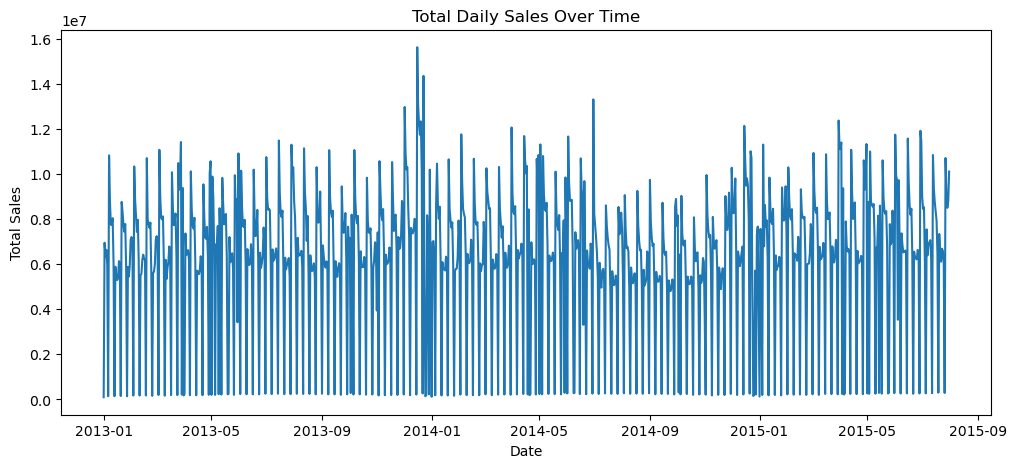

In [8]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"],daily_sales["Sales"])

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

There is a clear repeat pattern in the data, especially weekly behaviour, values are consistent overall and not constant up or down trends.

## 4. Train/Test Split

In [9]:
test_size = 60

# Currently the test split is last 2 months
# iloc func inculdes all but the last 60 days (train)
train_ts = daily_sales.iloc[:-test_size].copy()
# iloc func includes only the  last 60 days (test)
test_ts = daily_sales.iloc[-test_size:].copy()

print("Training period:")
print(train_ts["Date"].min(), "to", train_ts["Date"].max())

print("\nTesting period:")
print(test_ts["Date"].min(), "to", test_ts["Date"].max())

print("\nTraining observations:", len(train_ts))
print("Testing observations:", len(test_ts))

Training period:
2013-01-01 00:00:00 to 2015-06-01 00:00:00

Testing period:
2015-06-02 00:00:00 to 2015-07-31 00:00:00

Training observations: 882
Testing observations: 60


## 5. Naive Forecast Baseline Model

In [10]:
# start from the last training value, then shift the actual test values by one day
naive_pred = np.empty(len(test_ts))

naive_pred[0] = train_ts["Sales"].iloc[-1]
naive_pred[1:] = test_ts["Sales"].iloc[:-1].values


In [34]:
naive_pred 
"""
ordered by Time / Chronological Order,
(from oldest test date to newest test date),
matching the exact row order of test_ts
"""

'\nordered by Time / Chronological Order,\n(from oldest test date to newest test date),\nmatching the exact row order of test_ts\n'

In [12]:
naive_results = pd.DataFrame({
    "Date": test_ts["Date"],            # The timestamp/date of each test observation
    "Actual": test_ts["Sales"],          # The true ground truth sales numbers (y_true)
    "Naive Prediction": naive_pred      # The predictions generated by the naive baseline (y_pred)
})

naive_results.head()
# Prediction is last known sales value from training
# Prediction(today) is actual sales from yesterday


,Date,Actual,Naive Prediction
882,2015-06-02,9925193,11743615.0
883,2015-06-03,9731791,9925193.0
884,2015-06-04,3534231,9731791.0
885,2015-06-05,9724893,3534231.0
886,2015-06-06,6478518,9724893.0


## 6. Naive Forecast Model Evaluation

In [13]:
# Benchmark eval - later models will be compared to this
naive_mae = mean_absolute_error(
    test_ts["Sales"],
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test_ts["Sales"],
        naive_pred)
)

print(f"Naive MAE: {naive_mae:,.2f}") # avg absolute prediction error
print(f"Naive RMSE: {naive_rmse:,.2f}") # penalizes larger errors more heavily

Naive MAE: 2,746,028.78
Naive RMSE: 4,278,452.33


RMSE is substantially larger than MAE. That suggests the naive model has some particularly large forecasting errors, not just consistently medium-sized ones

## 7. Seasonal Naive Forecast Model

In [ ]:
# seasonality = 7 as in '7 days per week' 
seasonal_period = 7

combined_sales = pd.concat([
    train_ts["Sales"],
    test_ts["Sales"]
])

seasonal_naive_pred = (
    combined_sales
    .shift(seasonal_period)
    .iloc[-len(test_ts):]
    .values # Extracts the raw array of predictions aligned with the test dates
)


For every tested day, we look back exactly 7 days to the same day of previous week

In [15]:
# Evaluation of seasonal model
seasonal_naive_mae = mean_absolute_error(
    test_ts["Sales"],
    seasonal_naive_pred
)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        test_ts["Sales"],
        seasonal_naive_pred)
)

print(f"Seasonal Naive MAE: {seasonal_naive_mae:,.2f}")
print(f"Seasonal Naive RMSE: {seasonal_naive_rmse:,.2f}")

Seasonal Naive MAE: 2,084,717.68
Seasonal Naive RMSE: 2,570,396.03


Compared to Naive Forecast Model, Seasonal Model has better metrics.MAE dropped by about 24% and RMSE dropped by about 40%. Can conclude that using data from previous week is much more accurate than yestarday's data.

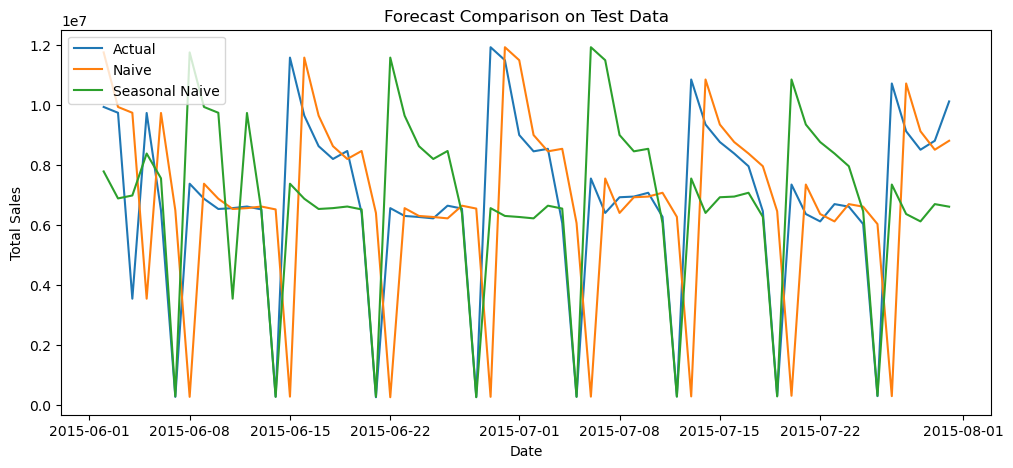

In [16]:
# visualization of actual vs predictions vals
plt.figure(figsize=(12, 5))

plt.plot(
    test_ts["Date"],
    test_ts["Sales"],
    label="Actual"
)

plt.plot(
    test_ts["Date"],
    naive_pred,
    label="Naive"
)

plt.plot(
    test_ts["Date"],
    seasonal_naive_pred,
    label="Seasonal Naive"
)

plt.title("Forecast Comparison on Test Data")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()
plt.show()

The seasonal naive model outperformed the naive baseline, indicating that weekly seasonality is an important characteristic of Rossmann sales. While both models struggle with some fluctuations, using sales from the same day in the previous week provides substantially better forecasts than relying only on the previous day sales.

## 8. Stationarity Check

In [17]:
# First check whether the statistical properties of the series are
# reasonably stable over time

In [35]:
# * Using ADF test 
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_ts["Sales"])

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

"""
p-value < 0.05 -  evidence that the series is stationary
p-value ≥ 0.05 -  not enough evidence that it's stationary

Null hypothesis (H₀): the series is non-stationary
Alternative hypothesis (H₁): the series is stationary
"""

ADF Statistic: -4.7392
p-value: 0.0001


"\np-value < 0.05 -  evidence that the series is stationary\np-value ≥ 0.05 -  not enough evidence that it's stationary\n\nNull hypothesis (H₀): the series is non-stationary\nAlternative hypothesis (H₁): the series is stationary\n"

Since p-values is less than 0.05, ther is evidence that series is stationary


-> Since the evidence points that data is stationary, we can use no diff or d = 0

## 9. ACF and PACF Analysis

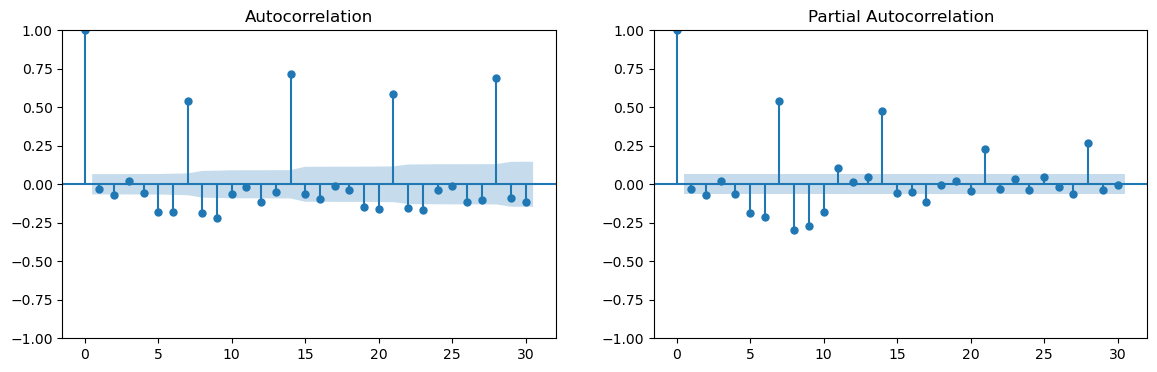

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig,axes = plt.subplots(1,2, figsize = (14,4))

plot_acf(train_ts["Sales"], lags = 30, ax = axes[0])
plot_pacf(train_ts["Sales"], lags = 30, ax = axes[1])


plt.show()

##### ACF and PACF Findings

The ACF and PACF plots show strong spikes at lags 7, 14, 21, and 28, indicating strong weekly seasonality in daily sales.

This supports the earlier finding that the Seasonal Naive model outperformed the Naive model. Therefore, weekly seasonality should be considered when building forecasting models.

A simple ARIMA model will be used as a non-seasonal benchmark, followed by a seasonal model to better capture the weekly pattern.

## 10. ARIMA Model

In [20]:
# ARIMA(p,d,q)

# p = Autoregression (prev values)
# d = differncing b/w values
# q = past errors or Moving AVG

In [36]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_ts["Sales"],
    order = (7,0,0)# 7 prev days, 0 diff, start with no MA val
    # Imp - 7 doesnt mean "Weekly sesonality" it means model uses lag = 7 days prev
)
# ARIMA(7,0,0)
# Uses: 1, 2, 3, 4, 5, 6, 7 days ago

arima_result = arima_model.fit()

arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  882
Model:                 ARIMA(7, 0, 0)   Log Likelihood              -14248.404
Date:                Sat, 29 Aug 2026   AIC                          28514.807
Time:                        21:43:39   BIC                          28557.847
Sample:                             0   HQIC                         28531.265
                                - 882                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.196e+06   1.23e+05     50.479      0.000    5.96e+06    6.44e+06
ar.L1          0.0332      0.020      1.676      0.094      -0.006       0.072
ar.L2          0.0219      0.027      0.799      0.424      -0.032       0.076
ar.L3          0.0511      0.028      1.829      0.067      -0.004       0.106
ar.L4         -0.0857      0.027     -3.168      0.002      -0.139      -0.033
ar.L5         -0.1454      0.033     -4.353      0.000      -0.211      -0.080
ar.L6         -0.1725      0.036     -4.746      0.000      -0.244      -0.101
ar.L7          0.5480      0.024     23.276      0.000       0.502       0.594
sigma2      6.254e+12      0.005   1.28e+15      0.000    6.25e+12    6.25e+12
===================================================================================
Ljung-Box (L1) (Q):                  25.30   Jarque-Bera (JB):                76.62
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                             0.25
Prob(H) (two-sided):                  0.46   Kurtosis:                         4.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.22e+30. Standard errors may be unstable.
"""

Results show more proof on seasonality, i.e sales from 7 days ago have a strong relationship with current sales.
Important - Lag 7 p-val = 0.000

In [41]:
# Test ARIMA on the test data of 60 days
arima_forecast = arima_result.forecast(
    steps=len(test_ts)
)
"""
Forecast() - forecast steps out-of-sample into the future
 (starting right after training data ends).
Predict()- predict values over any specified index range
(can be in-sample training period or out-of-sample).
"""

arima_forecast.head()

882    6.769036e+06
883    5.841176e+06
884    6.842409e+06
885    7.584152e+06
886    7.143732e+06
Name: predicted_mean, dtype: float64

In [45]:
# convert series to array
arima_forecast = np.asarray(arima_forecast)

In [47]:
# test set evaluation
arima_mae = mean_absolute_error(
    test_ts["Sales"],
    arima_forecast
)

arima_rmse = np.sqrt( # convert back to normal values since nums are squared
    mean_squared_error(
        test_ts["Sales"],
        arima_forecast)
)

print(f"ARIMA MAE: {arima_mae:,.2f}")
print(f"ARIMA RMSE: {arima_rmse:,.2f}")

ARIMA MAE: 2,075,114.51
ARIMA RMSE: 2,727,431.88


# Evaluation Metrics
| Model          |           MAE |          RMSE |
| -------------- | ------------: | ------------: |
| Naive          |     2,746,029 |     4,278,452 |
| Seasonal Naive |     2,084,718 | **2,570,396** |
| ARIMA(7,0,0)   | **2,075,115** |     2,727,432 |

* MAE, RMSE the lower the better




ARIMA has the best MAE, but only slightly better than Seasonal Naive.
Seasonal Naive has the best RMSE, meaning it handles the largest errors better overall.
So far, ARIMA is not clearly dominating the very simple Seasonal Naive model.

# 8. SARIMA Model

In [24]:
# SARIMA(p,d,q) × (P,D,Q,s)

# P = seasonal autoregressive terms
# D = seasonal differencing
# Q = seasonal moving average terms
# s = seasonal period

#SARIMA(...)(...,7)
#Explicitly models the repeating weekly cycle:
#7, 14, 21, 28 days ago

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_ts["Sales"],
    order = (1,0,0),
    seasonal_order =(1,0,0,7)
)
"""
Non-seasonal:
p = 1   → previous day relationship
d = 0   → no regular differencing
q = 0   → no MA term

Seasonal:
P = 1   → previous seasonal cycle relationship
D = 0   → no seasonal differencing initially
Q = 0   → no seasonal MA term
s = 7   → weekly seasonality
"""

sarima_result =sarima_model.fit(disp = False)

sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                             Sales   No. Observations:                  882
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood              -14452.669
Date:                           Sat, 29 Aug 2026   AIC                          28911.337
Time:                                   18:02:31   BIC                          28925.684
Sample:                                        0   HQIC                         28916.823
                                           - 882                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4290      0.068      6.269      0.000       0.295       0.563
ar.S.L7        0.8316      0.037     22.438      0.000       0.759       0.904
sigma2      1.808e+13   8.27e-16   2.19e+28      0.000    1.81e+13    1.81e+13
===================================================================================
Ljung-Box (L1) (Q):                  22.68   Jarque-Bera (JB):               514.15
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.18
Prob(H) (two-sided):                  0.92   Kurtosis:                         6.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.7e+43. Standard errors may be unstable.
"""

##### Seasonal lag 7 is very strong
ar.S.L7 = 0.8316
p-value = 0.000
ar.L1 = 0.4290 (ARIMA)

This means the relationship with the same point one week earlier is extremely strong in this model.

Weekly seasonal component is especially important.

##### Why this Model- As Analysis Concluded:
ADF suggested no regular differencing needed

Strong weekly seasonality

Lag 7 was extremely important in ARIMA

Seasonal period is clearly 7

In [26]:
# Forecast SARIMA (Failure)
sarima_forecast = sarima_result.forecast(
    steps=len(test_ts)
)

sarima_forecast = np.asarray(sarima_forecast)
sarima_mae = mean_absolute_error(
    test_ts["Sales"],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test_ts["Sales"],
        sarima_forecast)
)

print(f"SARIMA MAE: {sarima_mae:,.2f}")
print(f"SARIMA RMSE: {sarima_rmse:,.2f}")

SARIMA MAE: 3,206,889.62
SARIMA RMSE: 3,950,009.31


## Evaluation Metrics
| Model                   |           MAE |          RMSE |
| ----------------------- | ------------: | ------------: |
| Naive                   |     2,746,029 |     4,278,452 |
| Seasonal Naive          |     2,084,718 | **2,570,396** |
| ARIMA(7,0,0)            | **2,075,115** |     2,727,432 |
| SARIMA(1,0,0)×(1,0,0,7) |     3,206,890 |     3,950,009 |

Config is bad and this specific config SARIMA(1,0,0)×(1,0,0,7) is much worse

Model is **untuned** and requires tuning as of now

A more complex model does not automatically mean a better forecast

---

Best MAE: ARIMA

Best RMSE: Seasonal Naive

SARIMA needs better parameter selection




## 9. SARIMA Model Comparison

In [27]:
# Try some configs for sarima
sarima_configs = [
    ((1, 0, 0), (1, 0, 0, 7)),
    ((1, 0, 1), (1, 0, 0, 7)),
    ((2, 0, 0), (1, 0, 0, 7)),
    ((1, 0, 0), (1, 0, 1, 7))
]

In [28]:
# loop through each config above, and append results 
sarima_results = []
for order, seasonal_order in sarima_configs:

    model = SARIMAX(
        train_ts["Sales"],
        order=order,
        seasonal_order=seasonal_order
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=len(test_ts))

    mae = mean_absolute_error(
        test_ts["Sales"],
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_ts["Sales"],
            forecast)
    )

    sarima_results.append({
        "Order": order,
        "Seasonal Order": seasonal_order,
        "MAE": mae,
        "RMSE": rmse}
    )

c:\Users\prade\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [29]:
#  convert the sarima_results(list of dicts) to DataFrame
sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df.sort_values("MAE")

,Order,Seasonal Order,MAE,RMSE
3,"(1, 0, 0)","(1, 0, 1, 7)",1.122513e+06,1.540606e+06
0,"(1, 0, 0)","(1, 0, 0, 7)",3.206890e+06,3.950009e+06
2,"(2, 0, 0)","(1, 0, 0, 7)",3.426228e+06,4.262050e+06
1,"(1, 0, 1)","(1, 0, 0, 7)",3.554157e+06,4.367235e+06


## Evaluation Metrics - Updated Config
| Model           |           MAE |          RMSE |
| --------------- | ------------: | ------------: |
| Naive           |     2,746,029 |     4,278,452 |
| Seasonal Naive  |     2,084,718 |     2,570,396 |
| ARIMA(7,0,0)    |     2,075,115 |     2,727,432 |
| Initial SARIMA  |     3,206,890 |     3,950,009 |
| **Best SARIMA** | **1,122,513** | **1,540,606** |

Best SARIMA config as of now - **SARIMA(1,0,0) × (1,0,1,7)**

46% MAE reduction compared with Seasonal Naive

AR(1) for recent day-to-day behavior

Seasonal AR with period 7 for weekly repetition

Seasonal MA to model repeating weekly forecast errors/shocks



In [30]:
# Save the best configured SARIMA model, i.e SARIMA(1,0,0) × (1,0,1,7)
best_sarima_model = SARIMAX(
    train_ts["Sales"],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 7)
)

best_sarima_result = best_sarima_model.fit(disp=False)
best_sarima_forecast = best_sarima_result.forecast(
    steps=len(test_ts)
)

## 10. Final Model Comparison

In [31]:
final_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(7,0,0)",
        "SARIMA(1,0,0)x(1,0,0,7)",
        "Best SARIMA(1,0,0)x(1,0,1,7)"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae,
        arima_mae,
        sarima_mae,
        1122513
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse,
        arima_rmse,
        sarima_rmse,
        1540606
        
    ]
})

final_results.sort_values("MAE")

,Model,MAE,RMSE
4,"Best SARIMA(1,0,0)x(1,0,1,7)",1.122513e+06,1.540606e+06
2,"ARIMA(7,0,0)",2.075115e+06,2.727432e+06
1,Seasonal Naive,2.084718e+06,2.570396e+06
0,Naive,2.746029e+06,4.278452e+06
3,"SARIMA(1,0,0)x(1,0,0,7)",3.206890e+06,3.950009e+06


# Final Evaluation Metrics

| Rank | Model                            |           MAE |          RMSE |
| ---- | -------------------------------- | ------------: | ------------: |
| 1    | **Best SARIMA(1,0,0)×(1,0,1,7)** | **1,122,513** | **1,540,606** |
| 2    | ARIMA(7,0,0)                     |     2,075,115 |     2,727,432 |
| 3    | Seasonal Naive                   |     2,084,718 |     2,570,396 |
| 4    | Naive                            |     2,746,029 |     4,278,452 |
| 5    | SARIMA(1,0,0)×(1,0,0,7)          |     3,206,890 |     3,950,009 |

* Best SARIMA(1,0,0)×(1,0,1,7) - SARIMA with config = (1,0,0)×(1,0,1,7) is produces the best results
* Seasonal MA component made a huge difference




## 11. Final forecast visualization

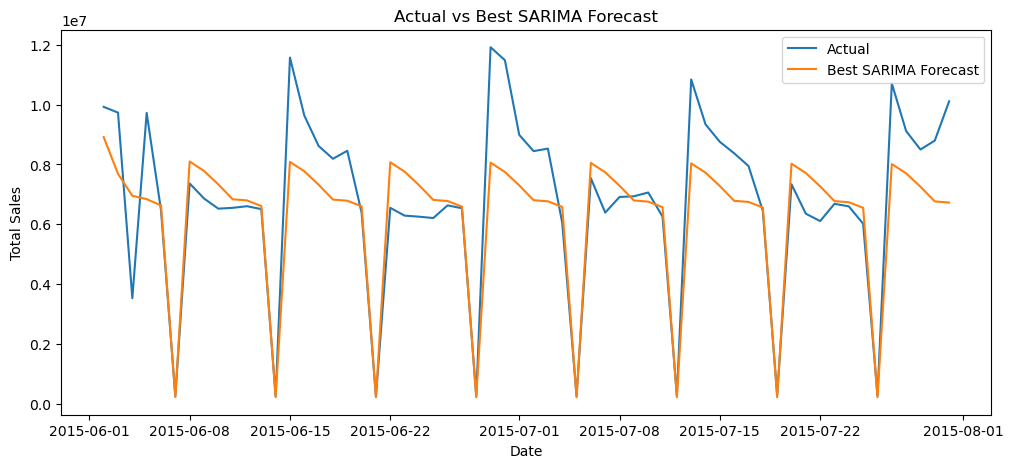

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_ts["Date"],
    test_ts["Sales"],
    label="Actual"
)

plt.plot(
    test_ts["Date"],
    best_sarima_forecast,
    label="Best SARIMA Forecast"
)

plt.title("Actual vs Best SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()
plt.show()

## 12. Residual Diagnostics

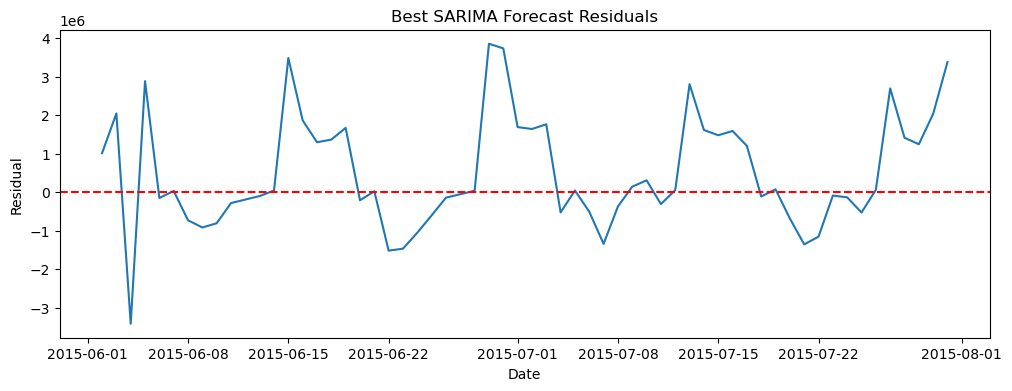

In [ ]:
"""
residual = Actual Sales - Predicted Sales
Near 0 = good prediction
Positive = model predicted too low
Negative = model predicted too high
"""

residuals = test_ts["Sales"].values - best_sarima_forecast # actual test vals - sarima pred values
plt.figure(figsize=(12, 4))

plt.plot(test_ts["Date"], residuals)
plt.axhline(y=0, linestyle="--", color = 'r')

plt.title("Best SARIMA Forecast Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

In [49]:
# Testing accuracy of current best model
actual = test_ts["Sales"].values
predicted = best_sarima_forecast

# 1. MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# 2. WAPE (Weighted Absolute Percentage Error - standard for retail)
wape = (np.sum(np.abs(actual - predicted)) / np.sum(actual)) * 100

# 3. Overall Forecast Accuracy %
accuracy = 100 - wape

print(f"MAPE (Average Error %): {mape:.2f}%")
print(f"WAPE (Volume Error %):  {wape:.2f}%")
print(f"Forecast Accuracy     : {accuracy:.2f}%")


MAPE (Average Error %): 15.94%
WAPE (Volume Error %):  16.51%
Forecast Accuracy     : 83.49%


### Residual Diagnostics

The residuals generally fluctuate around zero, suggesting that the model captures the main sales patterns reasonably well. However, some large positive and negative residuals remain, indicating that the model still misses certain unusual changes in sales.

Residuals move around the zero line, which is what we want.
There is no obvious continuous upward or downward trend.
However, there are some large positive and negative spikes, roughly up to ±3 to 4 million.

* Large positive spike - model underpredicted
* Large negative spike - model overpredicted
* Close to zero - prediction was good

---

# Conclusion

This notebook developed and evaluated multiple time series forecasting models for total daily Rossmann sales.

The analysis found strong weekly seasonality, supported by the ACF and PACF plots, with significant patterns at lags 7, 14, 21, and 28.

Several models were evaluated:

| Model | MAE | RMSE |
|---|---:|---:|
| Naive | 2,746,029 | 4,278,452 |
| Seasonal Naive | 2,084,718 | 2,570,396 |
| ARIMA(7,0,0) | 2,075,115 | 2,727,432 |
| Best SARIMA(1,0,0)x(1,0,1,7) | **1,122,513** | **1,540,606** |

The best SARIMA model achieved the lowest MAE and RMSE, showing that explicitly modeling weekly seasonality improved forecasting performance.

The residual analysis showed that errors generally fluctuated around zero, although some large errors remained during unusual changes in sales.

---

